In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [7]:
img = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (224, 224))  # 사이즈 고정

In [8]:
# DFT (주파수 변환)
def dft_image(img):
    dft = np.fft.fft2(img)              # 2D 푸리에 변환
    dft_shift = np.fft.fftshift(dft)    # 중심을 이미지 중앙으로 이동
    return dft_shift

# IDFT (역변환)
def idft_image(dft_shift):
    f_ishift = np.fft.ifftshift(dft_shift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)         # 복소수 → 실수
    return img_back

In [9]:
# DFT 수행
dft_shift = dft_image(img)

# 주파수 영역 시각화를 위한 로그 스펙트럼
magnitude_spectrum = 20 * np.log(np.abs(dft_shift) + 1)

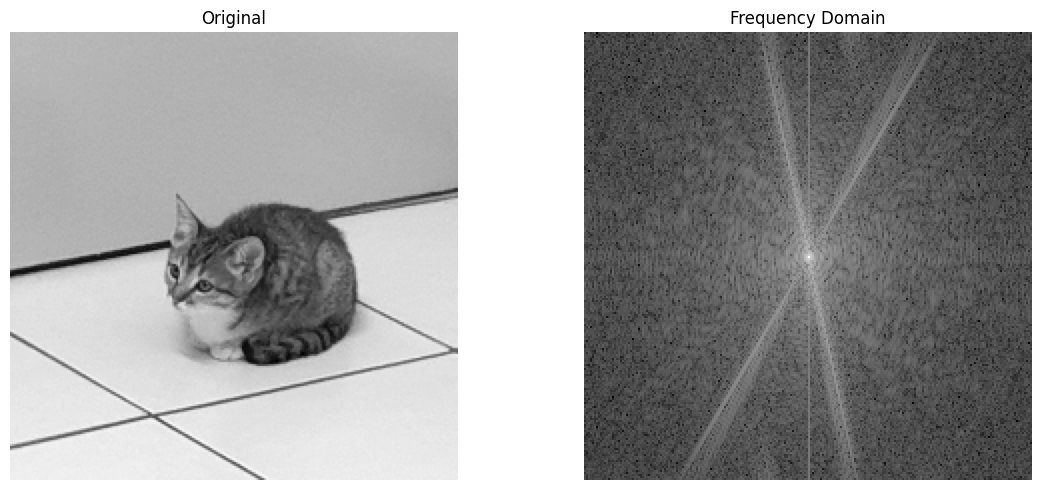

In [10]:
# 결과 출력력
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Frequency Domain")
plt.axis('off')

plt.tight_layout()
plt.show()